In [2]:
import pandas as pd
import matplotlib.pyplot as plt


jsonl_list = [
    'Metadata_textbook_teacher.jsonl',
    'Metadata_textbook.jsonl',
    'Taiwan_merged.jsonl',
    'China_merged.jsonl',
    '學測歷史.jsonl'
]


# read the jsonl file
df = pd.read_json("data_jsonl/China_merged.jsonl", lines=True, encoding="utf-8")

# 看一下前幾列確認欄位
print(df.head())
print("-"*50)
print(df.columns)

  source_type                                            content title  \
0       中國史史料                                                 史记    史记   
1       中國史史料  史记卷一 五帝本纪第一\n卷二 夏本纪第二\n卷三 殷本纪第三\n卷四 周本纪第四\n卷五 ...    史记   
2       中國史史料  世家第八\n卷三十九 晋世家第九\n卷四十 楚世家第十\n卷四十一 越王句践世家第十一\n卷...    史记   
3       中國史史料  原君虞卿列传第十六\n卷七十七 魏公子列传第十七\n卷七十八 春申君列传第十八\n卷七十九 ...    史记   
4       中國史史料  百十 匈奴列传第五十\n卷一百一十一 卫将军骠骑列传第五十一\n卷一百一十二 平津侯主父列传...    史记   

   chunk_index  
0            0  
1            1  
2            2  
3            3  
4            4  
--------------------------------------------------
Index(['source_type', 'content', 'title', 'chunk_index'], dtype='object')


In [2]:
df_textbook = df[df['source_type']=="textbook"]
df_textbook.head(5)

,content,source_type,subject,topic,keywords,chapter,title,subjectsubject
0,有學者主張語言發源地的語言分支較多。南島語目前有四大支，其中三支發源於臺灣，故臺灣被認為是南...,textbook,史前臺灣,文化,"[南島語, 語言分支, 起源地, 臺灣, 擴散]",V.1/Ch.1/臺灣的原住民族,起源地的語言較具多樣性,NaN
1,體質人類學主要透過研究人類生理構造、化石與現代靈長類，追溯人類起源與演化過程。,textbook,史前臺灣,文化,"[體質人類學, 人類生理構造, 化石, 靈長類, 演化過程]",V.1/Ch.1/臺灣的原住民族,體質人類學,NaN
2,南島語族是指使用南島語言（Austronesian languages）的民族，其範圍北起臺...,textbook,原住民,文化,"[南島語族, 南島語言, 臺灣, 紐西蘭, 復活節島]",V.1/Ch.1/臺灣的原住民族,南島語族的定義,NaN
3,南島語族源於何處，眾說紛紜。早期學者多認為來自亞洲大陸東南部、南洋群島或臺灣。有相當多研究指...,textbook,史前臺灣,文化,"[南島語族, 起源地, 語言學家, 語言分歧, 擴散起點]",V.1/Ch.1/臺灣的原住民族,可能的起源地：臺灣,NaN
4,根據學者研究指出，南島語族大約在五、六千年前開始從臺灣向外擴散。最先來到菲律賓北部，再從東南...,textbook,史前臺灣,社會,"[南島語族, 擴散, 菲律賓, 夏威夷, 大洋洲]",V.1/Ch.1/臺灣的原住民族,航海擴散遍大洋,NaN


subject
中華民國       276
日治臺灣       254
清治臺灣       211
日本         120
明清         118
          ... 
第一次世界大戰      1
塞爾柱          1
第二次世界大戰      1
土耳其          1
奧地利          1
Name: count, Length: 71, dtype: int64


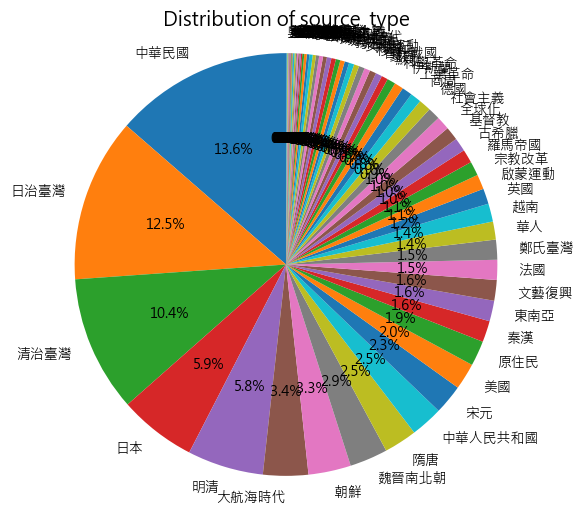

In [6]:
import matplotlib.pyplot as plt

# 2. 計算各種 source_type 的數量  topic
source_counts = df["subject"].value_counts()
plt.rcParams['font.sans-serif'] = [
    "Microsoft JhengHei",  # Windows 常見
]
print(source_counts)

# 3. 畫圓餅圖
plt.figure(figsize=(6, 6))
plt.pie(
    source_counts,
    labels=source_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    shadow = 0,
    # textprops = { 'backgroundcolor' : 'w',
    #                 'clip_on' : 0}
)

plt.title("Distribution of source_type", fontsize=14)
plt.axis("equal")  # 讓圓餅圖是圓的
plt.show()


In [4]:
print(source_counts)

subject
中華民國       276
日治臺灣       254
清治臺灣       211
日本         120
明清         118
          ... 
第一次世界大戰      1
塞爾柱          1
第二次世界大戰      1
土耳其          1
奧地利          1
Name: count, Length: 71, dtype: int64


## token 分布

In [3]:
import json, argparse, numpy as np, seaborn as sns , tiktoken, os
def load_jsonl_as_df(file_path):
    """Load JSONL file into pandas DataFrame."""
    try:
        df = pd.read_json(file_path, lines=True, encoding="utf-8")
        print(f"Loaded {len(df)} rows from {file_path}")
        return df
    except Exception as e:
        print(f"Error reading JSONL: {e}")
        return None
def analyze_df_tokens(df_subset, field_name):
    """Analyze token distribution for a subset DataFrame."""
    encoding = tiktoken.get_encoding("cl100k_base")
    token_counts = []

    for i, content in enumerate(df_subset[field_name]):
        if isinstance(content, str):
            num_tokens = len(encoding.encode(content))
            token_counts.append(num_tokens)
        else:
            print(f"Warning: row {i} field '{field_name}' is not string.")
    
    print(f"Processed {len(token_counts)} entries for subset.")
    return token_counts
def print_statistics(token_counts):
    """Prints statistical information about token counts."""
    if not token_counts:
        print("No token data to calculate statistics.")
        return

    stats = {
        "Total Entries": len(token_counts),
        "Average Tokens": f"{np.mean(token_counts):.2f}",
        "Median Tokens": np.median(token_counts),
        "Max Tokens": np.max(token_counts),
        "Min Tokens": np.min(token_counts),
        "Std Dev of Tokens": f"{np.std(token_counts):.2f}",
        "25th Percentile": np.percentile(token_counts, 25),
        "75th Percentile": np.percentile(token_counts, 75)
    }
    
    print("\n--- Token Statistics ---")
    for key, value in stats.items():
        print(f"{key}: {value}")
    print("------------------------\n")

def plot_distribution(token_counts, field_name, output_filename="token_distribution.png"):
    """Plots and saves the token count distribution."""
    if not token_counts:
        print("No data to plot.")
        return

    plt.figure(figsize=(12, 7))
    sns.set_style("whitegrid")
    
    # Plot histogram and kernel density estimate
    sns.histplot(token_counts, kde=True, bins=50)
    
    # Add statistical lines
    plt.axvline(np.mean(token_counts), color='r', linestyle='--', linewidth=2, label=f'Mean: {np.mean(token_counts):.2f}')
    plt.axvline(np.median(token_counts), color='g', linestyle='-', linewidth=2, label=f'Median: {np.median(token_counts)}')
    
    plt.title(f"Token Count Distribution for '{field_name}'", fontsize=16)
    plt.xlabel('Number of Tokens', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.legend()
    
    try:
        plt.savefig(output_filename)
        print(f"Chart saved to: {os.path.abspath(output_filename)}")
    except Exception as e:
        print(f"Error saving chart: {e}")

In [ ]:

file_path = "data_jsonl/tiktoken.jsonl"
field = "content"
df = load_jsonl_as_df(file_path)
if df is None:
        exit()

for name, df_subset in subsets.items():
        print(f"\n=== Analyzing: {name} ({len(df_subset)} rows) ===")
        
        if df_subset.empty:
            print(f"Skipping {name}: no rows.")
            continue

        # 計算 token 分布
        token_counts = analyze_df_tokens(df_subset, field)

        # 印出統計
        print_statistics(token_counts)

        # 畫圖
        output_file = f"token_distribution_{name}.png"
        plot_distribution(token_counts, f"{field} of {name}", output_file)
        

Error reading JSONL: Expected object or value


/tmp/ipykernel_551604/47123692.py:5: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_json(file_path, lines=True, encoding="utf-8")


TypeError: 'NoneType' object is not subscriptable

: 

In [ ]:
import os
import pandas as pd

BASE_DIR = "data_jsonl"

jsonl_list = [
    'Metadata_textbook_teacher.jsonl',
    'Metadata_textbook.jsonl',
    'Taiwan_merged.jsonl',
    'China_merged.jsonl',
    '學測歷史.jsonl'
]

def summarize_file(path: str):
    print("=" * 80)
    print(f"檔名：{os.path.basename(path)}")

    df = pd.read_json(path, lines=True, encoding="utf-8")
    n_rows = len(df)
    print(f"總筆數（rows / chunks）：{n_rows}")

    # 判斷內容欄位是 content 還是 text
    if "content" in df.columns:
        text_col = "content"
    elif "text" in df.columns:
        text_col = "text"
    else:
        print("⚠ 找不到 content / text 欄位，略過字數統計")
        text_col = None

    # source_type 統計
    if "source_type" in df.columns:
        n_sources = df["source_type"].nunique()
        print(f"不同 source_type 數量：{n_sources}")
        print("source_type 前 5 名（依筆數）：")
        print(df["source_type"].value_counts().head(5))
    else:
        print("⚠ 沒有 source_type 欄位")

    # 文字長度統計
    if text_col is not None:
        df["_len_chars"] = df[text_col].astype(str).str.len()
        total_chars = int(df["_len_chars"].sum())
        mean_chars = float(df["_len_chars"].mean())
        median_chars = float(df["_len_chars"].median())
        max_chars = int(df["_len_chars"].max())

        print("\n內容字數統計（以字元數 rough 估）：")
        print(f"  總字數：{total_chars:,}")
        print(f"  平均每 chunk 字數：{mean_chars:.1f}")
        print(f"  中位數字數：{median_chars:.1f}")
        print(f"  最大 chunk 字數：{max_chars}")
    else:
        print("\n⚠ 無法計算內容字數（缺 content/text 欄位）")

    # subject / topic 分布（如果有）
    if "subject" in df.columns:
        print("\nsubject 分布（前 5 名）：")
        print(df["subject"].value_counts().head(5))

    if "topic" in df.columns:
        print("\ntopic 分布（前 5 名）：")
        print(df["topic"].value_counts().head(5))

    print()  # 空行好看一點

3

def main():
    for fname in jsonl_list:
        path = os.path.join(BASE_DIR, fname)
        if not os.path.exists(path):
            print(f"⚠ 找不到檔案：{path}，略過")
            continue
        summarize_file(path)


if __name__ == "__main__":
    main()


檔名：Metadata_textbook_teacher.jsonl
總筆數（rows / chunks）：1164
不同 source_type 數量：1
source_type 前 5 名（依筆數）：
source_type
teachers_book    1164
Name: count, dtype: int64

內容字數統計（以字元數 rough 估）：
  總字數：496,485
  平均每 chunk 字數：426.5
  中位數字數：396.0
  最大 chunk 字數：1769

subject 分布（前 5 名）：
subject
中華民國    169
日治臺灣    151
清治臺灣    134
明清       80
日本       76
Name: count, dtype: int64

topic 分布（前 5 名）：
topic
政治    473
文化    299
社會    199
經濟    193
Name: count, dtype: int64

檔名：Metadata_textbook.jsonl
總筆數（rows / chunks）：865
不同 source_type 數量：1
source_type 前 5 名（依筆數）：
source_type
textbook    865
Name: count, dtype: int64

內容字數統計（以字元數 rough 估）：
  總字數：173,425
  平均每 chunk 字數：200.5
  中位數字數：156.0
  最大 chunk 字數：972

subject 分布（前 5 名）：
subject
中華民國    107
日治臺灣    103
清治臺灣     77
日本       44
明清       38
Name: count, dtype: int64

topic 分布（前 5 名）：
topic
政治    333
文化    205
社會    196
經濟    131
Name: count, dtype: int64

檔名：Taiwan_merged.jsonl
總筆數（rows / chunks）：4911
不同 source_type 數量：1
source_type 前 5 名（依筆數）：
source_

讀取 data_jsonl\Metadata_textbook_teacher.jsonl ...
  總字數：496,485
讀取 data_jsonl\Metadata_textbook.jsonl ...
  總字數：173,425
讀取 data_jsonl\Taiwan_merged.jsonl ...
  總字數：2,211,946
讀取 data_jsonl\China_merged.jsonl ...
  總字數：2,024,395
讀取 data_jsonl\學測歷史.jsonl ...
  總字數：12,546

各檔案統計結果：
  label  total_chars
0  教師用書       496485
1    課本       173425
2   臺灣史      2211946
3   中國史      2024395
4    學測        12546


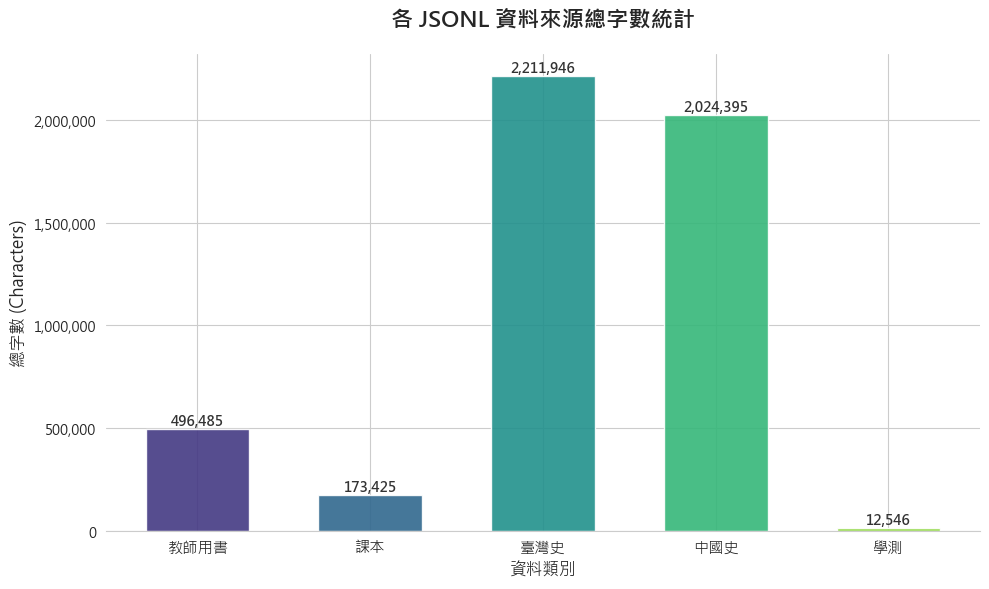

In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  # 用於美化圖表

# --- 1. 設定與準備 ---
BASE_DIR = "data_jsonl"

jsonl_list = [
    'Metadata_textbook_teacher.jsonl',
    'Metadata_textbook.jsonl',
    'Taiwan_merged.jsonl',
    'China_merged.jsonl',
    '學測歷史.jsonl'
]

# 建立檔名與顯示名稱的對照表
name_mapping = {
    'Metadata_textbook_teacher.jsonl': '教師用書',
    'Metadata_textbook.jsonl': '課本',
    'Taiwan_merged.jsonl': '臺灣史',
    'China_merged.jsonl': '中國史',
    '學測歷史.jsonl': '學測'
}

total_chars = []

# --- 2. 讀取檔案與計算字數 (保留您原本的邏輯) ---
for fname in jsonl_list:
    path = os.path.join(BASE_DIR, fname)
    print(f"讀取 {path} ...")
    
    # 檢查檔案是否存在，避免報錯
    if not os.path.exists(path):
        print(f"⚠ 找不到檔案：{path}，跳過")
        total_chars.append(0)
        continue

    df = pd.read_json(path, lines=True, encoding="utf-8")

    # 判斷內容欄位名稱
    if "content" in df.columns:
        text_col = "content"
    elif "text" in df.columns:
        text_col = "text"
    else:
        print(f"⚠ {fname} 沒有 content/text 欄位，當作 0 字處理")
        total_chars.append(0)
        continue

    # 計算總字數
    chars = df[text_col].astype(str).str.len().sum()
    total_chars.append(chars)
    print(f"  總字數：{chars:,}")

# --- 3. 建立 DataFrame 並進行對照轉換 ---
stat_df = pd.DataFrame({
    "file": jsonl_list,
    "total_chars": total_chars,
})

# 新增 'label' 欄位：利用 map 將檔名轉換為中文簡稱
stat_df["label"] = stat_df["file"].map(name_mapping)

# 印出結果確認
print("\n各檔案統計結果：")
print(stat_df[["label", "total_chars"]]) # 只印出簡稱和字數比較乾淨

# --- 4. 繪製美化後的圖表 ---
# 設定繪圖風格
sns.set_style("whitegrid")

# 設定中文字型 (Windows 使用 Microsoft JhengHei)
plt.rcParams['font.sans-serif'] = ["Microsoft JhengHei"]
plt.rcParams['axes.unicode_minus'] = False 

plt.figure(figsize=(10, 6))

# 使用漸層顏色
colors = sns.color_palette("viridis", n_colors=len(stat_df))

# 畫長條圖：X 軸使用新的 "label"
bars = plt.bar(stat_df["label"], stat_df["total_chars"], color=colors, alpha=0.9, width=0.6)

# 設定標題與軸標籤
plt.title("各 JSONL 資料來源總字數統計", fontsize=16, fontweight="bold", pad=20)
plt.ylabel("總字數 (Characters)", fontsize=12)
plt.xlabel("資料類別", fontsize=12)
plt.xticks(fontsize=11) # X 軸字體大小

# 設定 Y 軸數值格式為千分位 (例如 1,000,000)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

# 移除上方與右方的邊框
sns.despine(left=True)

# 在柱子上顯示數值
for bar in bars:
    height = bar.get_height()
    if height > 0:
        plt.text(
            bar.get_x() + bar.get_width() / 2, 
            height, 
            f"{int(height):,}", 
            ha="center", 
            va="bottom", 
            fontsize=10, 
            fontweight="bold", 
            color="#333333"
        )

plt.tight_layout()
plt.show()